In [2]:
import os
os.makedirs("plots", exist_ok=True)
print("Plots folder created!")

Plots folder created!


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from stable_baselines3 import SAC, PPO, TD3, DDPG
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym
import os

os.makedirs("plots", exist_ok=True)

plt.style.use('dark_background')
COLORS = {
    "SAC":  "#00B4D8",
    "PPO":  "#06D6A0",
    "TD3":  "#EF476F",
    "DDPG": "#FFD166"
}
colors = list(COLORS.values())
print("Setup Done!")

Setup Done!


##  All Results (Pre-collected)

In [4]:
# All Results from All Experiments
# 1. Normal Environment - Phase 1 (1M timesteps)
phase1_results = {
    "names": ["SAC", "PPO", "TD3", "DDPG"],
    "means": [258.55, 291.67, 263.74, 151.56],
    "stds":  [1.60,   2.21,   61.31,  166.81]
}

# 2. Normal Environment - After Tuning
tuned_results = {
    "names": ["SAC", "PPO", "TD3", "DDPG"],
    "means": [290.35, 289.34, 296.80, 198.88],
    "stds":  [2.21,   1.98,   1.48,   123.71]
}

# 3. DDPG Experiments
ddpg_experiments = {
    "versions": ["DDPG v1\n(Original)",
                 "DDPG v2\n(Better Params)",
                 "DDPG v3\n(OU Noise+Bigger)"],
    "means": [151.56, 198.88, 226.92],
    "stds":  [166.81, 123.71, 117.08],
    "single_best": [None, None, 305.98]
}

# 4. Fixed Seed - Normal Environment
seeds = [42, 123, 456, 789]
seed_normal = {
    "SAC":  [290.27, -7.29, 292.58, 291.08],
    "PPO":  [288.89, 286.38, 289.02, 290.34],
    "TD3":  [295.13, 294.05, 296.64, 295.22],
    "DDPG": [92.51, 129.21, 142.55, 305.00]
}

# 5. Zero-shot Hardcore
seed_zeroshot = {
    "SAC":  [-83.78, -85.83, -62.20, -87.93],
    "PPO":  [-98.43, -89.38, -57.37, -68.34],
    "TD3":  [-73.16,  13.34, -50.54,  20.64],
    "DDPG": [-78.40, -97.64, -46.61, -83.43]
}

# 6. Hardcore v2 (After Training)
seed_hardcore_v2 = {
    "SAC":  [-15.45, 114.90, 146.72, 125.51],
    "PPO":  [-64.38,  88.79, -61.16,  64.94],
    "TD3":  [-63.95, 136.09, 108.70, 170.02],
    "DDPG": [-17.66, -59.98, -126.99, -108.91]
}

# 7. Curriculum Learning
seed_curriculum = {
    "SAC": [-96.23, 187.06, -53.60, -72.82]
}

# 8. GPU + SDE (Final Best)
seed_gpu_sde = {
    "SAC": [294.39, 295.03, 297.05, 290.37],
    "TD3": [15.30, 189.40, 170.48, 285.98],
    "PPO": [-86.66, -26.33, -66.44, -106.36]
}

gpu_eval = {
    "names": ["SAC", "TD3", "PPO"],
    "means": [205.73, 176.68, -86.43],
    "stds":  [124.03, 117.08, 25.88]
}

print("All results loaded!")

All results loaded!


## Phase 1 - Normal Benchmarking

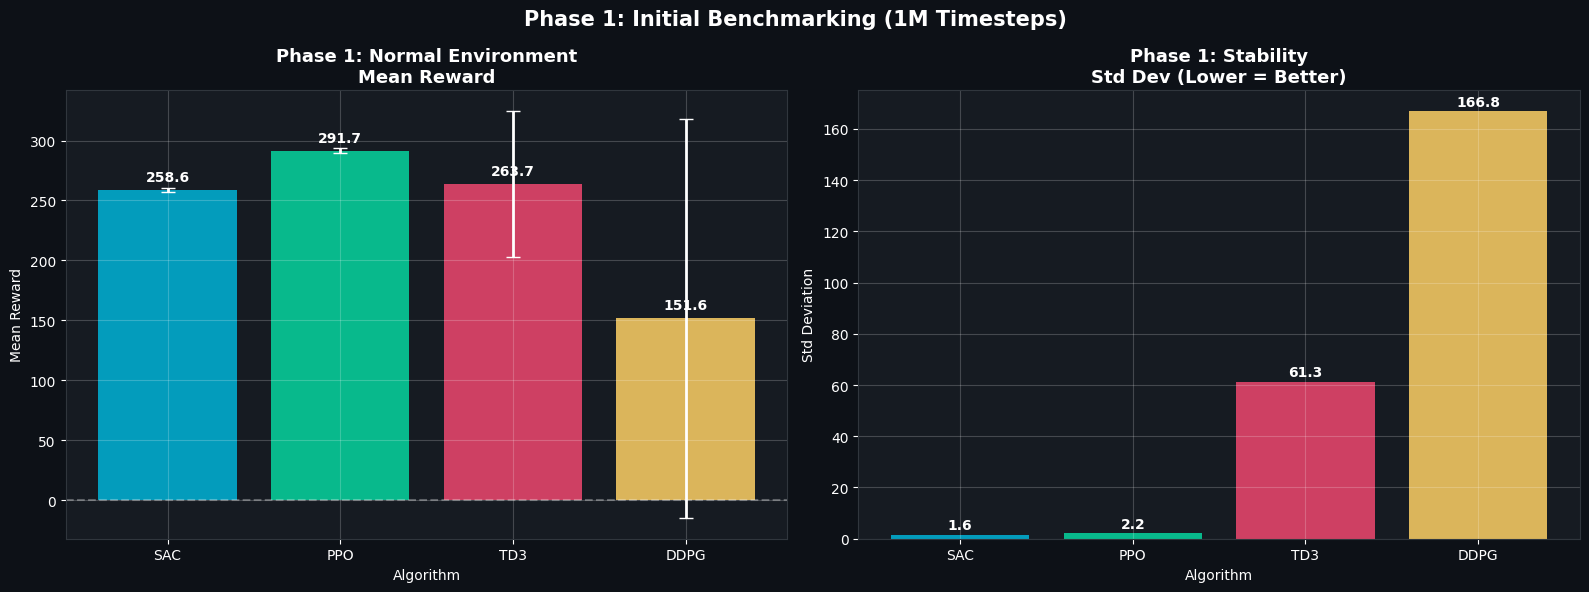

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Mean Reward
ax = axes[0]
ax.set_facecolor('#161B22')
bars = ax.bar(
    phase1_results["names"],
    phase1_results["means"],
    yerr    = phase1_results["stds"],
    capsize = 5,
    color   = colors,
    alpha   = 0.85,
    error_kw= dict(ecolor='white', linewidth=2)
)
ax.set_title("Phase 1: Normal Environment\nMean Reward",
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel("Algorithm", color='white')
ax.set_ylabel("Mean Reward", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
ax.axhline(y=0, color='white', linestyle='--', alpha=0.3)
for spine in ax.spines.values():
    spine.set_color('#30363D')
for bar, mean in zip(bars, phase1_results["means"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            f'{mean:.1f}',
            ha='center', va='bottom',
            color='white', fontweight='bold')

# Stability
ax = axes[1]
ax.set_facecolor('#161B22')
bars = ax.bar(
    phase1_results["names"],
    phase1_results["stds"],
    color   = colors,
    alpha   = 0.85,
)
ax.set_title("Phase 1: Stability\nStd Dev (Lower = Better)",
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel("Algorithm", color='white')
ax.set_ylabel("Std Deviation", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
for spine in ax.spines.values():
    spine.set_color('#30363D')
for bar, std in zip(bars, phase1_results["stds"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{std:.1f}',
            ha='center', va='bottom',
            color='white', fontweight='bold')

fig.suptitle("Phase 1: Initial Benchmarking (1M Timesteps)",
             color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/phase1_results.png", dpi=300,
            facecolor='#0D1117', bbox_inches='tight')
plt.show()

## DDPG Experiments

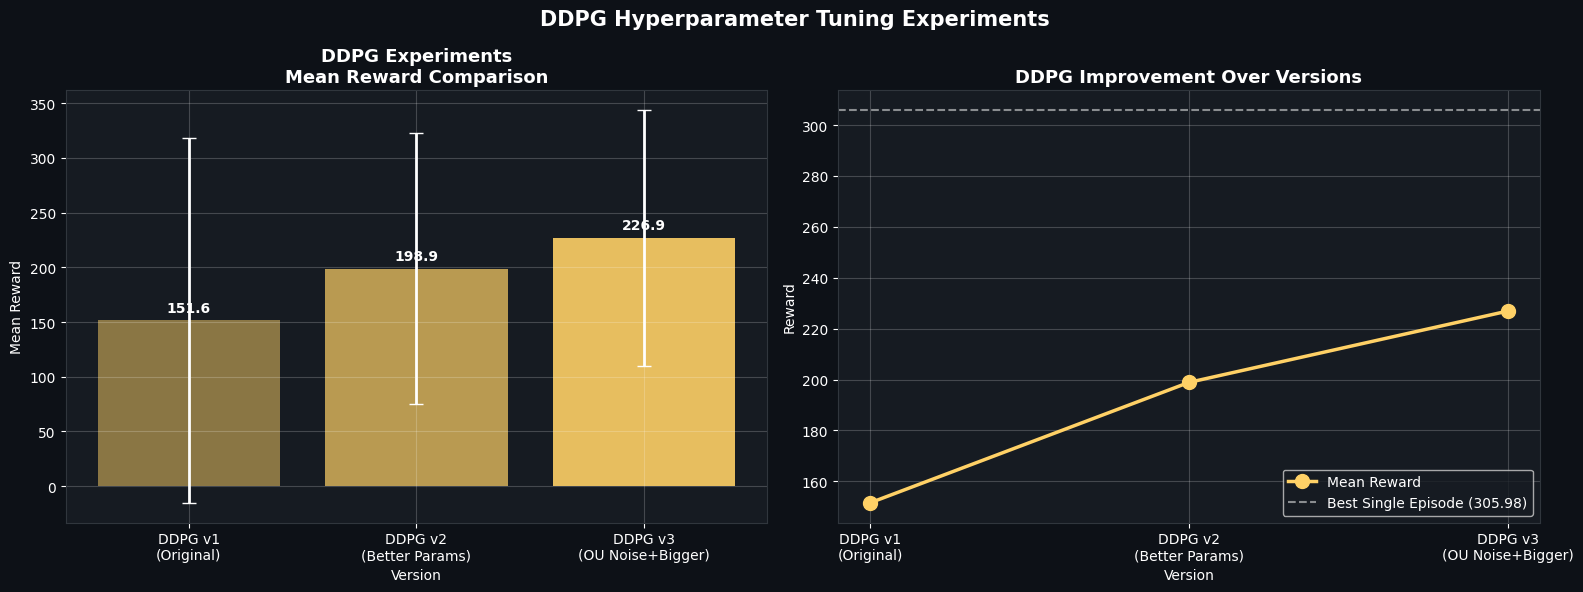

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Mean Reward Comparison
ax = axes[0]
ax.set_facecolor('#161B22')
ddpg_color = COLORS["DDPG"]

alphas   = [0.5, 0.7, 0.9]
versions = ddpg_experiments["versions"]
means    = ddpg_experiments["means"]
stds     = ddpg_experiments["stds"]

for i, (ver, mean, std, alpha) in enumerate(
    zip(versions, means, stds, alphas)
):
    bar = ax.bar(ver, mean,
                 yerr    = std,
                 capsize = 5,
                 color   = ddpg_color,
                 alpha   = alpha,  
                 error_kw= dict(ecolor='white',
                                linewidth=2))
    ax.text(i, mean + 5,
            f'{mean:.1f}',
            ha='center', va='bottom',
            color='white', fontweight='bold')

ax.set_title("DDPG Experiments\nMean Reward Comparison",
             color='white', fontsize=13,
             fontweight='bold')
ax.set_xlabel("Version", color='white')
ax.set_ylabel("Mean Reward", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
for spine in ax.spines.values():
    spine.set_color('#30363D')

# Best Single Episode
ax = axes[1]
ax.set_facecolor('#161B22')

improvement = [151.56, 198.88, 226.92]
ax.plot(ddpg_experiments["versions"],
        improvement, 'o-',
        color=ddpg_color, linewidth=2.5,
        markersize=10, label='Mean Reward')
ax.axhline(y=305.98, color='white',
           linestyle='--', alpha=0.5,
           label='Best Single Episode (305.98)')
ax.set_title("DDPG Improvement Over Versions",
             color='white', fontsize=13,
             fontweight='bold')
ax.set_xlabel("Version", color='white')
ax.set_ylabel("Reward", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
ax.legend(facecolor='#161B22', labelcolor='white')
for spine in ax.spines.values():
    spine.set_color('#30363D')

fig.suptitle(
    "DDPG Hyperparameter Tuning Experiments",
    color='white', fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig("plots/ddpg_experiments.png",
            dpi=300, facecolor='#0D1117',
            bbox_inches='tight')
plt.show()

## Fixed Seed - Normal vs Hardcore

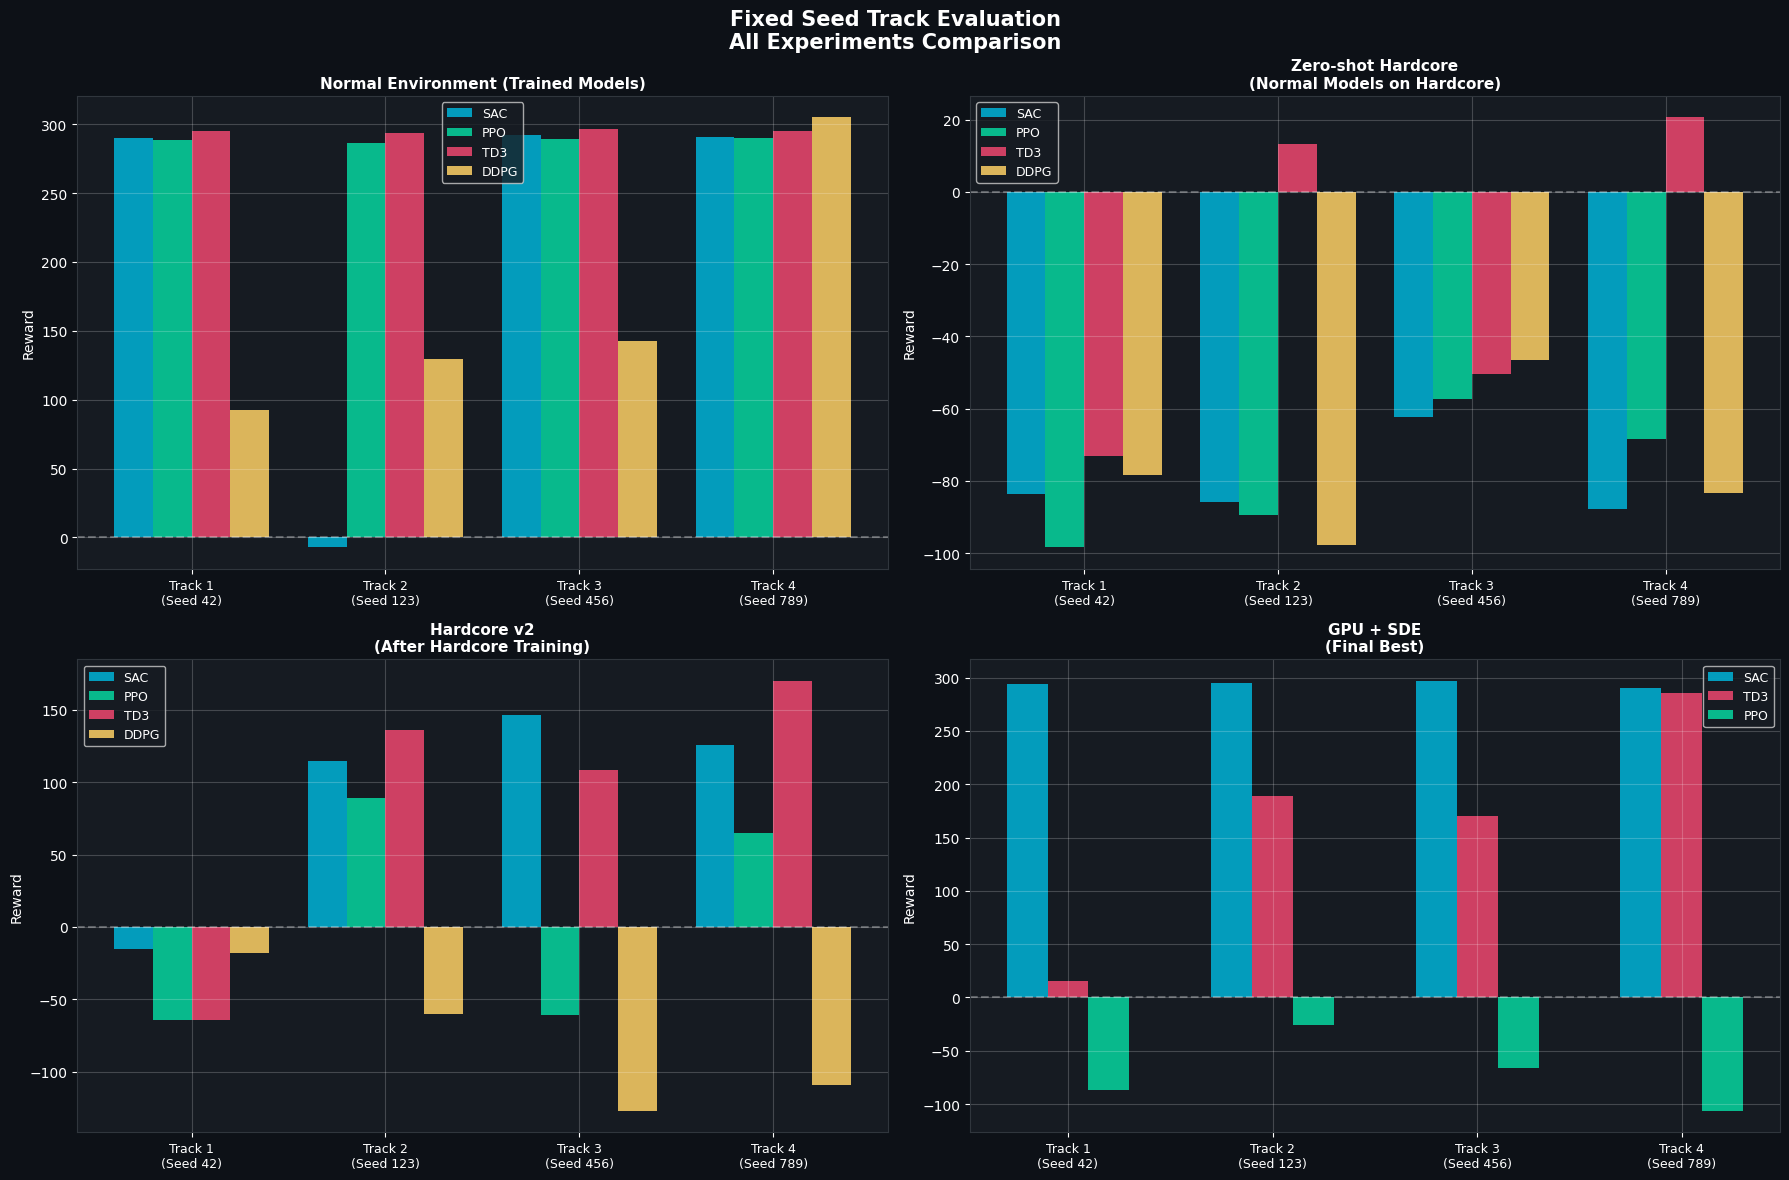

In [7]:
track_labels = ['Track 1\n(Seed 42)',
                'Track 2\n(Seed 123)',
                'Track 3\n(Seed 456)',
                'Track 4\n(Seed 789)']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor('#0D1117')
axes = axes.flatten()

datasets = [
    (seed_normal,     "Normal Environment (Trained Models)"),
    (seed_zeroshot,   "Zero-shot Hardcore\n(Normal Models on Hardcore)"),
    (seed_hardcore_v2,"Hardcore v2\n(After Hardcore Training)"),
    (seed_gpu_sde,    "GPU + SDE\n(Final Best)")
]

for ax_idx, (data, title) in enumerate(datasets):
    ax = axes[ax_idx]
    ax.set_facecolor('#161B22')

    x     = np.arange(4)
    width = 0.2
    alg_names = list(data.keys())

    for i, (name, values) in enumerate(data.items()):
        color = COLORS.get(name, '#FFFFFF')
        offset = (i - len(alg_names)/2 + 0.5) * width
        bars = ax.bar(x + offset, values,
                      width, label=name,
                      color=color, alpha=0.85)

    ax.set_title(title, color='white',
                 fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(track_labels,
                       color='white', fontsize=9)
    ax.set_ylabel("Reward", color='white')
    ax.tick_params(colors='white')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='white',
               linestyle='--', alpha=0.3)
    ax.legend(facecolor='#161B22',
              labelcolor='white', fontsize=9)
    for spine in ax.spines.values():
        spine.set_color('#30363D')

fig.suptitle(
    "Fixed Seed Track Evaluation\nAll Experiments Comparison",
    color='white', fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig("plots/fixed_seed_comparison.png",
            dpi=300, facecolor='#0D1117',
            bbox_inches='tight')
plt.show()

## Training Progress

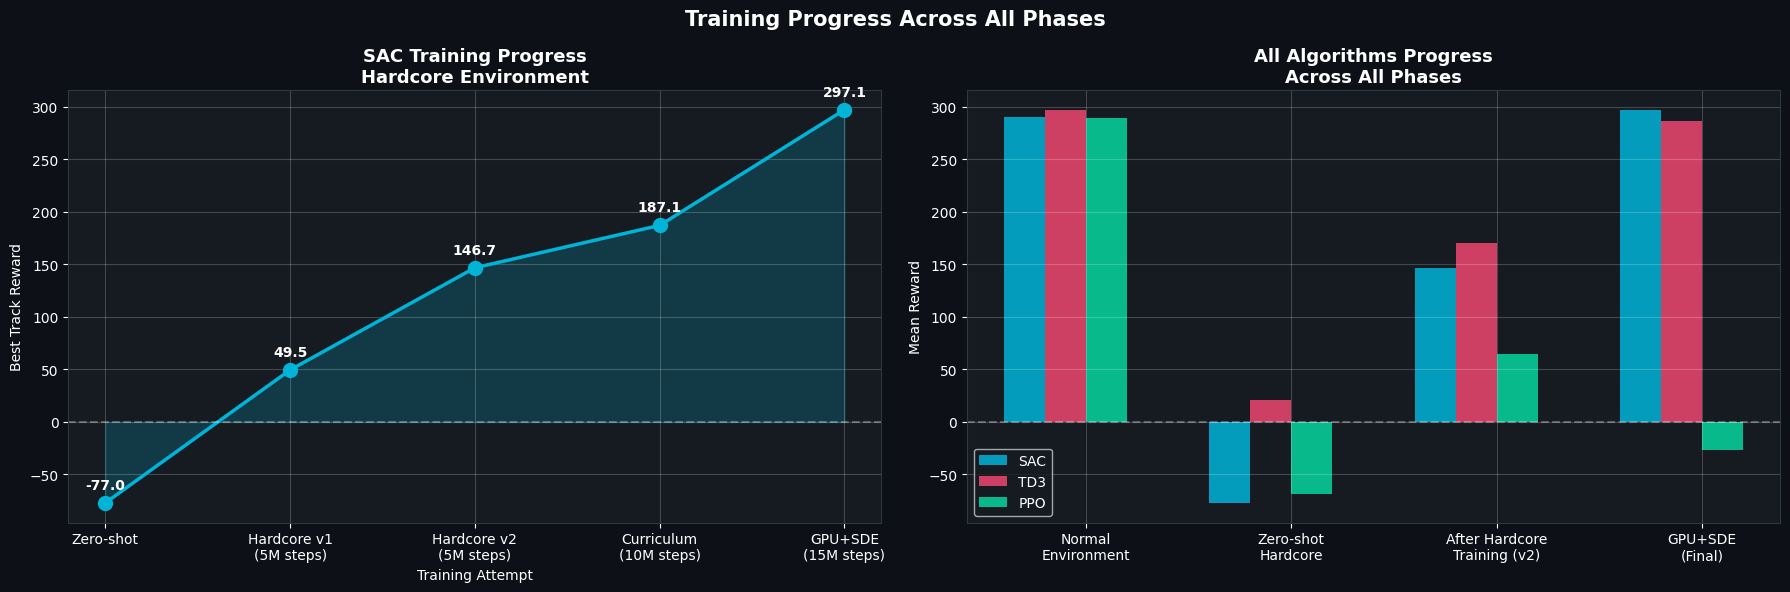

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0D1117')

# Hardcore Training Progress
ax = axes[0]
ax.set_facecolor('#161B22')

attempts = [
    "Zero-shot",
    "Hardcore v1\n(5M steps)",
    "Hardcore v2\n(5M steps)",
    "Curriculum\n(10M steps)",
    "GPU+SDE\n(15M steps)"
]

sac_progress = [-77.0, 49.50, 146.72, 187.06, 297.05]

ax.plot(attempts, sac_progress, 'o-',
        color=COLORS["SAC"],
        linewidth=2.5, markersize=10)
ax.fill_between(range(len(attempts)),
                sac_progress,
                alpha=0.2, color=COLORS["SAC"])
for i, val in enumerate(sac_progress):
    ax.annotate(f'{val:.1f}',
                (i, val),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center', color='white',
                fontweight='bold')
ax.axhline(y=0, color='white',
           linestyle='--', alpha=0.3)
ax.set_title("SAC Training Progress\nHardcore Environment",
             color='white', fontsize=13,
             fontweight='bold')
ax.set_xlabel("Training Attempt", color='white')
ax.set_ylabel("Best Track Reward", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
for spine in ax.spines.values():
    spine.set_color('#30363D')

# Final Comparison
ax = axes[1]
ax.set_facecolor('#161B22')

categories = ['Normal\nEnvironment',
              'Zero-shot\nHardcore',
              'After Hardcore\nTraining (v2)',
              'GPU+SDE\n(Final)']

sac_all  = [290.35, -77.0, 146.72, 297.05]
td3_all  = [296.80, 20.64, 170.02, 285.98]
ppo_all  = [289.34, -68.34, 64.94, -26.33]
ddpg_all = [226.92, -83.43, -108.91, None]

x     = np.arange(len(categories))
width = 0.2

for i, (name, vals, color) in enumerate([
    ("SAC",  sac_all,  COLORS["SAC"]),
    ("TD3",  td3_all,  COLORS["TD3"]),
    ("PPO",  ppo_all,  COLORS["PPO"]),
]):
    valid_vals = [v if v is not None else 0 for v in vals]
    ax.bar(x + (i-1.5)*width, valid_vals,
           width, label=name,
           color=color, alpha=0.85)

ax.set_title("All Algorithms Progress\nAcross All Phases",
             color='white', fontsize=13,
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, color='white')
ax.set_ylabel("Mean Reward", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
ax.axhline(y=0, color='white',
           linestyle='--', alpha=0.3)
ax.legend(facecolor='#161B22', labelcolor='white')
for spine in ax.spines.values():
    spine.set_color('#30363D')

fig.suptitle("Training Progress Across All Phases",
             color='white', fontsize=15,
             fontweight='bold')
plt.tight_layout()
plt.savefig("plots/training_progress.png",
            dpi=300, facecolor='#0D1117',
            bbox_inches='tight')
plt.show()

## Learning Curves

In [9]:
import os

print("Available logs:")
for root, dirs, files in os.walk("logs"):
    for file in files:
        if file == "evaluations.npz":
            print(os.path.join(root, file))

Available logs:
logs\best\PPO\evaluations.npz
logs\best\PPO_hardcore\evaluations.npz
logs\best\SAC\evaluations.npz
logs\best\SAC_hardcore\evaluations.npz
logs\best\TD3\evaluations.npz
logs\best\TD3_hardcore\evaluations.npz
logs\curriculum\phase1_500steps\evaluations.npz
logs\curriculum\phase2_1000steps\evaluations.npz
logs\curriculum\phase3_2000steps\evaluations.npz
logs\DDPG\evaluations.npz
logs\DDPG_v2\evaluations.npz
logs\DDPG_v3\evaluations.npz
logs\gpu_sde\PPO_hardcore\evaluations.npz
logs\gpu_sde\PPO_normal\evaluations.npz
logs\gpu_sde\SAC_hardcore\evaluations.npz
logs\gpu_sde\SAC_normal\evaluations.npz
logs\gpu_sde\TD3_hardcore\evaluations.npz
logs\gpu_sde\TD3_normal\evaluations.npz
logs\hardcore\DDPG\evaluations.npz
logs\hardcore\PPO\evaluations.npz
logs\hardcore\SAC\evaluations.npz
logs\hardcore\TD3\evaluations.npz
logs\hardcore_v2\DDPG\evaluations.npz
logs\hardcore_v2\PPO\evaluations.npz
logs\hardcore_v2\SAC\evaluations.npz
logs\hardcore_v2\TD3\evaluations.npz
logs\PPO\evalua

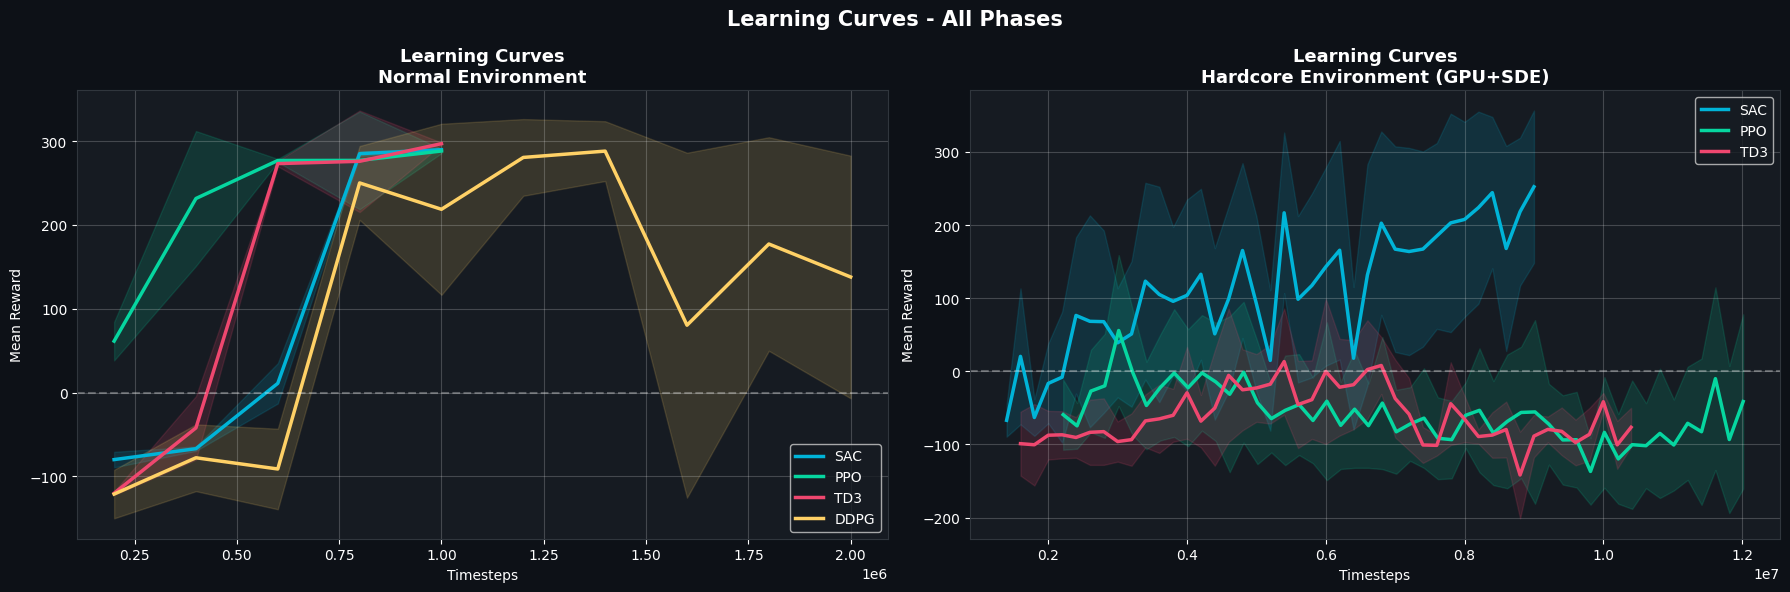

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0D1117')

# 1. Normal Learning Curves
ax = axes[0]
ax.set_facecolor('#161B22')

normal_logs = {
    "SAC":  "logs/SAC/evaluations.npz",
    "PPO":  "logs/PPO/evaluations.npz",
    "TD3":  "logs/TD3/evaluations.npz",
    "DDPG": "logs/DDPG_v3/evaluations.npz"
}

for name, log_path in normal_logs.items():
    if os.path.exists(log_path):
        data      = np.load(log_path)
        timesteps = data['timesteps']
        results_  = data['results']
        mean_r    = results_.mean(axis=1)
        std_r     = results_.std(axis=1)
        ax.plot(timesteps, mean_r,
                label=name,
                color=COLORS[name],
                linewidth=2.5)
        ax.fill_between(
            timesteps,
            mean_r - std_r,
            mean_r + std_r,
            alpha=0.15,
            color=COLORS[name]
        )

ax.set_title(
    "Learning Curves\nNormal Environment",
    color='white', fontsize=13,
    fontweight='bold'
)
ax.set_xlabel("Timesteps", color='white')
ax.set_ylabel("Mean Reward", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
ax.legend(facecolor='#161B22',
          labelcolor='white')
ax.axhline(y=0, color='white',
           linestyle='--', alpha=0.3)
for spine in ax.spines.values():
    spine.set_color('#30363D')

# 2. Hardcore Learning Curves
ax = axes[1]
ax.set_facecolor('#161B22')

hardcore_logs = {
    "SAC":  "logs/best/SAC_hardcore/evaluations.npz",
    "PPO":  "logs/best/PPO_hardcore/evaluations.npz",
    "TD3":  "logs/best/TD3_hardcore/evaluations.npz",
}

for name, log_path in hardcore_logs.items():
    if os.path.exists(log_path):
        data      = np.load(log_path)
        timesteps = data['timesteps']
        results_  = data['results']
        mean_r    = results_.mean(axis=1)
        std_r     = results_.std(axis=1)
        ax.plot(timesteps, mean_r,
                label=name,
                color=COLORS[name],
                linewidth=2.5)
        ax.fill_between(
            timesteps,
            mean_r - std_r,
            mean_r + std_r,
            alpha=0.15,
            color=COLORS[name]
        )
    else:
        print(f"Not found: {log_path}")

ax.set_title(
    "Learning Curves\nHardcore Environment (GPU+SDE)",
    color='white', fontsize=13,
    fontweight='bold'
)
ax.set_xlabel("Timesteps", color='white')
ax.set_ylabel("Mean Reward", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
ax.legend(facecolor='#161B22',
          labelcolor='white')
ax.axhline(y=0, color='white',
           linestyle='--', alpha=0.3)
for spine in ax.spines.values():
    spine.set_color('#30363D')

fig.suptitle(
    "Learning Curves - All Phases",
    color='white', fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig("plots/learning_curves.png",
            dpi=300, facecolor='#0D1117',
            bbox_inches='tight')
plt.show()

## Final Summary

C:\Users\dell\AppData\Local\Temp\ipykernel_23920\2607293642.py:111: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("plots/final_summary.png",
C:\Users\dell\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


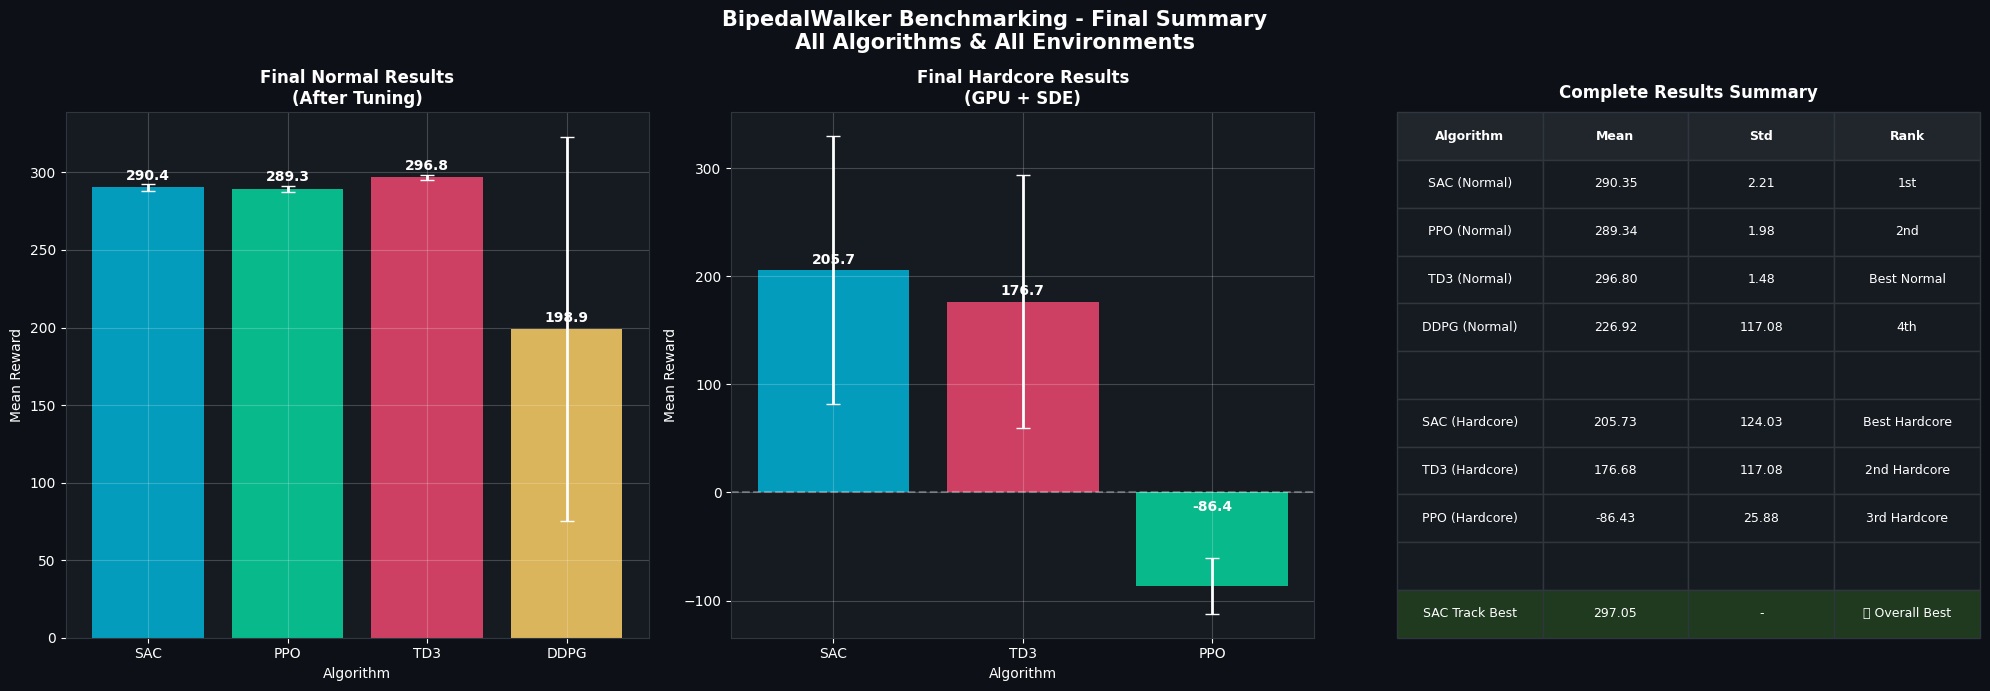


FINAL RESULTS SUMMARY
Algorithm                  Mean        Std
--- Normal Environment ---
SAC                      290.35       2.21
PPO                      289.34       1.98
TD3                      296.80       1.48
DDPG                     198.88     123.71

--- Hardcore Environment (GPU+SDE) ---
SAC                      205.73     124.03
TD3                      176.68     117.08
PPO                      -86.43      25.88

Best Overall: SAC (GPU+SDE)
Best Track:   SAC Track 3 = 297.05


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor('#0D1117')

# 1. Final Normal Results
ax = axes[0]
ax.set_facecolor('#161B22')
bars = ax.bar(
    tuned_results["names"],
    tuned_results["means"],
    yerr    = tuned_results["stds"],
    capsize = 5,
    color   = colors,
    alpha   = 0.85,
    error_kw= dict(ecolor='white', linewidth=2)
)
ax.set_title("Final Normal Results\n(After Tuning)",
             color='white', fontsize=12,
             fontweight='bold')
ax.set_xlabel("Algorithm", color='white')
ax.set_ylabel("Mean Reward", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
for spine in ax.spines.values():
    spine.set_color('#30363D')
for bar, mean in zip(bars, tuned_results["means"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f'{mean:.1f}',
            ha='center', va='bottom',
            color='white', fontweight='bold')

# 2. Final GPU+SDE Results
ax = axes[1]
ax.set_facecolor('#161B22')
bars = ax.bar(
    gpu_eval["names"],
    gpu_eval["means"],
    yerr    = gpu_eval["stds"],
    capsize = 5,
    color   = [COLORS[n] for n in gpu_eval["names"]],
    alpha   = 0.85,
    error_kw= dict(ecolor='white', linewidth=2)
)
ax.set_title("Final Hardcore Results\n(GPU + SDE)",
             color='white', fontsize=12,
             fontweight='bold')
ax.set_xlabel("Algorithm", color='white')
ax.set_ylabel("Mean Reward", color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
ax.axhline(y=0, color='white',
           linestyle='--', alpha=0.3)
for spine in ax.spines.values():
    spine.set_color('#30363D')
for bar, mean in zip(bars, gpu_eval["means"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3 if mean > 0 else -20,
            f'{mean:.1f}',
            ha='center', va='bottom',
            color='white', fontweight='bold')

# 3. Best Results Summary
ax = axes[2]
ax.set_facecolor('#161B22')
ax.axis('off')

summary_data = [
    ["SAC (Normal)",   "290.35", "2.21",  "1st"],
    ["PPO (Normal)",   "289.34", "1.98",  "2nd"],
    ["TD3 (Normal)",   "296.80", "1.48",  "Best Normal"],
    ["DDPG (Normal)",  "226.92", "117.08","4th"],
    ["", "", "", ""],
    ["SAC (Hardcore)", "205.73", "124.03","Best Hardcore"],
    ["TD3 (Hardcore)", "176.68", "117.08","2nd Hardcore"],
    ["PPO (Hardcore)", "-86.43", "25.88", "3rd Hardcore"],
    ["", "", "", ""],
    ["SAC Track Best", "297.05", "-",     "🏆 Overall Best"],
]

table = ax.table(
    cellText  = summary_data,
    colLabels = ['Algorithm', 'Mean', 'Std', 'Rank'],
    cellLoc   = 'center',
    loc       = 'center',
    bbox      = [0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#161B22')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#30363D')
    if row == 0:
        cell.set_facecolor('#21262D')
        cell.set_text_props(color='white',
                            fontweight='bold')
    if row == len(summary_data) and col >= 0:
        cell.set_facecolor('#1F3A1F')

ax.set_title("Complete Results Summary",
             color='white', fontsize=12,
             fontweight='bold', pad=10)

fig.suptitle(
    "BipedalWalker Benchmarking - Final Summary\n"
    "All Algorithms & All Environments",
    color='white', fontsize=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig("plots/final_summary.png",
            dpi=300, facecolor='#0D1117',
            bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"{'Algorithm':<20} {'Mean':>10} {'Std':>10}")
print("="*60)
print("--- Normal Environment ---")
for name, mean, std in zip(
    tuned_results["names"],
    tuned_results["means"],
    tuned_results["stds"]
):
    print(f"{name:<20} {mean:>10.2f} {std:>10.2f}")
print("\n--- Hardcore Environment (GPU+SDE) ---")
for name, mean, std in zip(
    gpu_eval["names"],
    gpu_eval["means"],
    gpu_eval["stds"]
):
    print(f"{name:<20} {mean:>10.2f} {std:>10.2f}")
print("="*60)
print("\nBest Overall: SAC (GPU+SDE)")
print("Best Track:   SAC Track 3 = 297.05")
print("="*60)